  體型 耳朵形狀 尾巴 是否叫  類別
0  小    長  短   否  兔子
1  中    短  長   是   狗
2  中    短  長   否  狐狸
3  小    短  長   是   貓
4  小    短  短   否  兔子
5  中    短  長   是   狗
6  小    長  短   否  兔子
7  大    短  長   否  狐狸
8  小    長  短   是   貓
9  中    短  長   是   狗
模型準確率: 1.0

分類報告:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



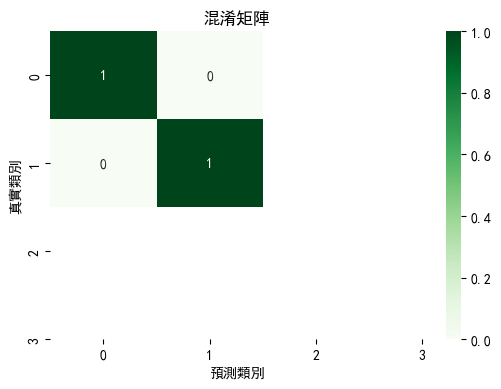

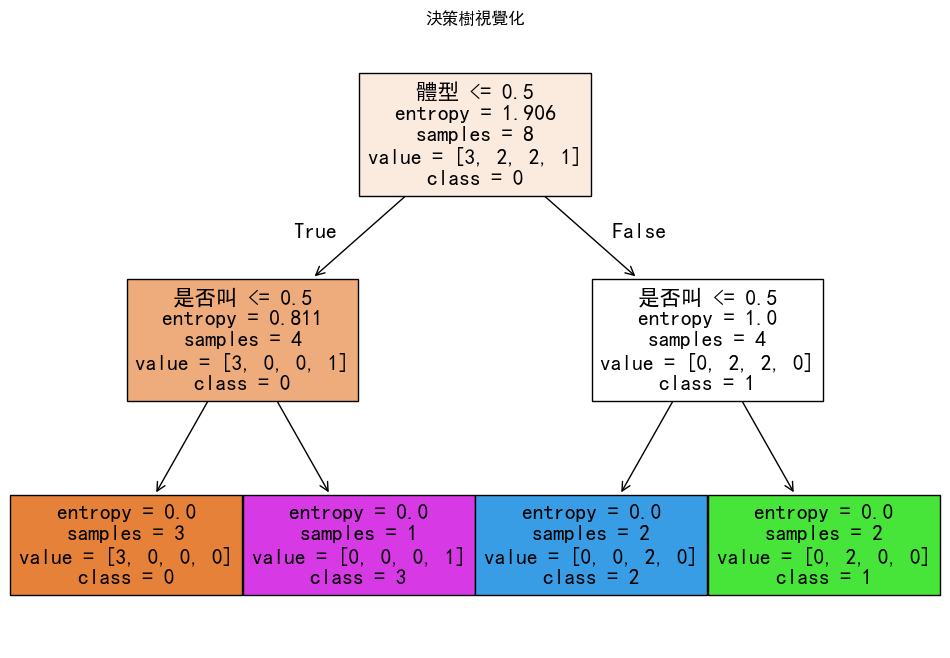

In [2]:
# 實驗三：決策樹分類（動物分類實驗）

# 步驟 1：導入必要的庫
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib as mpl

# 設定中文顯示
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

# 步驟 2：設計數據集

data = {
    '體型': ['小', '中', '中', '小', '小', '中', '小', '大', '小', '中'],
    '耳朵形狀': ['長', '短', '短', '短', '短', '短', '長', '短', '長', '短'],
    '尾巴': ['短', '長', '長', '長', '短', '長', '短', '長', '短', '長'],
    '是否叫': ['否', '是', '否', '是', '否', '是', '否', '否', '是', '是'],
    '類別': ['兔子', '狗', '狐狸', '貓', '兔子', '狗', '兔子', '狐狸', '貓', '狗']
}

# 轉換成DataFrame
df = pd.DataFrame(data)
print(df)

# 步驟 3：數據預處理
# 將類別特徵轉成數值特徵
for col in ['體型', '耳朵形狀', '是否叫', '類別', '耳朵形狀']:
    le = pd.factorize(df[col])[0]
    df[col] = le

X = df[['體型', '耳朵形狀', '是否叫']]
y = df['類別']

# 分割訓練集與測試集
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 步驟 4：建立與訓練決策樹模型
clf = DecisionTreeClassifier(criterion='entropy', max_depth=3)
clf.fit(X_train, y_train)

# 步驟 5：模型評估
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 預測
y_pred = clf.predict(X_test)

# 評估指標
print('模型準確率:', accuracy_score(y_test, y_pred))
print('\n分類報告:\n', classification_report(y_test, y_pred))

# 繪製混淆矩陣
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap='Greens', xticklabels=[str(cls) for cls in clf.classes_], yticklabels=[str(cls) for cls in clf.classes_])
plt.xlabel('預測類別')
plt.ylabel('真實類別')
plt.title('混淆矩陣')
plt.show()

# 步驟 5：視覺化決策樹
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=[str(cls) for cls in clf.classes_])
plt.title('決策樹視覺化')
plt.show()